In [ ]:
# Credits: Sections of this code are adapted from OpenAI's GPT-5.2.

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

In [ ]:
def normalize_longitude(lon):
    
    """
    Converts longitude values such that they fall between -180 and +180.

    Parameters
    ----------
    lon : float, list, or numpy array
        Longitude values that may be >180.

    Returns
    -------
    float or numpy array
        Adjusted longitude values.
    """

    lon = np.array(lon)
    lon = np.where(lon > 180, lon - 360, lon)

    return lon.item() if lon.size == 1 else lon

In [ ]:
def create_geometry(lat, lon, name, description):
    """
    Creates a Shapely geometry object (either Point or Linestring) for a GeoPandas GeoDataFrame.

    Parameters
    ----------
    lat : float, list, or numpy array
        Latitude values
    lon : float, list, or numpy array
        Longitude values
    name : str
        Feature's name
    description : str
        Feature's description

    Returns
    -------
    pandas.Series
        Row containing name, description, and geometry.
    """

    lon = normalize_longitude(lon)

    lat = np.atleast_1d(lat)
    lon = np.atleast_1d(lon)

    coords = list(zip(lon, lat))

    geometry = Point(coords[0]) if len(coords) == 1 else LineString(coords)

    return pd.Series({
        "name": name,
        "description": description,
        "geometry": geometry
    })

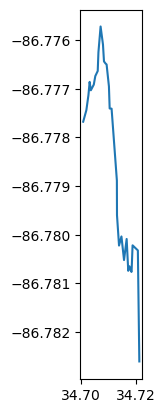

In [35]:
df = pd.read_csv("C:/Users/Craft/AES408/Data/bradford_lls.csv", header=None)
new_headers = ('LONGITUDE', 'LATITUDE')
df.columns = new_headers

coords = list(zip(df["LONGITUDE"], df["LATITUDE"]))
line = LineString(coords)

gdf = gpd.GeoDataFrame(
    {"name": ["Bradford Creek Greenway"],
     "geometry": [line]},
    crs="EPSG:4326"
)

gdf.plot()
gdf.to_file("bradford_creek_greenway.shp")